# Chapter 179 — Numerical Linear Algebra in Practice

> **Prerequisites:** ch036 (floating point errors), ch157 (matrix inverse), ch159 (determinants), ch161 (Gaussian elimination), ch163 (LU decomposition), ch173 (SVD)
> **You will learn:**
> - Why naive matrix operations fail on real data and how to detect it
> - What condition number means and how to interpret it
> - Why you should almost never compute a matrix inverse explicitly
> - How QR decomposition enables stable least-squares solving
> - The relationship between numerical stability and the singular value spectrum
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Every linear algebra operation you have studied in Part VI was described in exact arithmetic. In a computer, arithmetic is not exact — it is floating-point *(ch036 — Floating Point Errors)*. The interaction between finite-precision arithmetic and linear algebra operations is the subject of **numerical linear algebra**.

Two operations that are mathematically equivalent can produce wildly different results numerically. The difference is not a software bug — it is a structural property of the problem itself, quantified by the **condition number**.

This chapter is a bridge between the theoretical machinery of Part VI and the practical reality of computing with that machinery. Every project chapter that follows (ch180–ch191) will run correctly only if you understand when to trust a computed result and when to reach for a more stable algorithm.

**What problem does this solve?**  
Silent numerical failures: results that compute without errors but are garbage. A linear system that appears to have a unique solution but gives a different answer every time you perturb the data by 0.01%. A PCA that produces meaningless components because the covariance matrix is nearly singular.

**Common misconceptions:**
- "If it runs without error, the answer is correct." — numpy raises no exception for a singular or near-singular matrix solve. It returns a number. That number may be dominated by floating-point noise.
- "The condition number is only relevant for singular matrices." — A matrix with condition number 10^12 is far from singular in exact arithmetic but is numerically *indistinguishable* from singular in double precision (which has ~15-16 decimal digits).
- "Using `np.linalg.inv` is fine." — Computing the inverse explicitly is almost always slower, less accurate, and more numerically fragile than solving the linear system directly.

---

## 2. Intuition & Mental Models

**Condition number as amplification ratio.** Recall from ch177 that the spectral norm of a matrix is its maximum gain on any unit input. The condition number κ(A) = σ_max / σ_min is the ratio of the *largest* to the *smallest* gain. If κ = 10^6, a relative error of 10^-15 in the input (floating-point machine epsilon) can grow to a relative error of 10^-9 in the output — 6 orders of magnitude amplification. If κ = 10^16, the output error can reach 100%, making the result meaningless.

**Think of it as a nearly-flat surface.** Solving Ax = b is like finding the bottom of a bowl. If A is well-conditioned, the bowl is steep — small perturbations in b produce small changes in x. If A is ill-conditioned, the bowl is nearly flat — you cannot distinguish the bottom from points far away, because the height difference is within floating-point noise.

**QR decomposition as the stable alternative to the inverse.** Recall from ch162 (matrix factorization) that A = QR where Q is orthogonal (Qᵀ = Q⁻¹) and R is upper triangular. Solving Ax = b reduces to solving Rx = Qᵀb — a triangular system with no amplification through Q (orthogonal matrices have condition number 1). The condition number of R equals that of A, but the orthogonal factor is handled exactly.

**SVD as the universal stability diagnostic.** The singular values of A directly give the condition number (σ_max / σ_min), identify the near-null space (small σ directions), and enable the pseudoinverse for overdetermined or underdetermined systems. When in doubt about numerical stability, compute the SVD and inspect the singular value spectrum.

---

## 3. Visualization

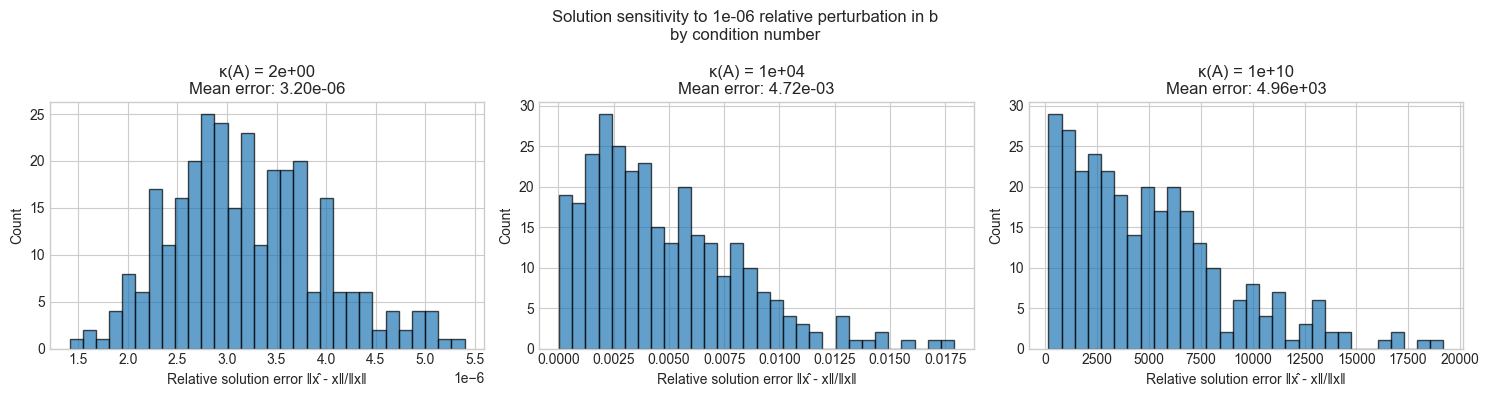

In [6]:
# --- Visualization: Condition number and solution sensitivity ---
# Show how the solution to Ax = b changes with tiny perturbations to b
# for well-conditioned vs ill-conditioned matrices.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)

def make_matrix_with_condition(n, cond, seed=0):
    """Construct a square matrix with specified condition number."""
    rng = np.random.default_rng(seed)
    U, _ = np.linalg.qr(rng.standard_normal((n, n)))
    V, _ = np.linalg.qr(rng.standard_normal((n, n)))
    sv = np.linspace(1, cond, n)
    return U @ np.diag(sv) @ V.T

N = 10
CONDITIONS = [1.5, 1e4, 1e10]
N_PERTURB = 300
NOISE_LEVEL = 1e-6

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, kappa in zip(axes, CONDITIONS):
    A = make_matrix_with_condition(N, kappa)
    x_true = np.ones(N)
    b = A @ x_true

    relative_errors = []
    for _ in range(N_PERTURB):
        # Perturb b by a tiny amount
        db = np.random.randn(N) * NOISE_LEVEL * np.linalg.norm(b)
        x_perturbed = np.linalg.solve(A, b + db)
        rel_err = np.linalg.norm(x_perturbed - x_true) / np.linalg.norm(x_true)
        relative_errors.append(rel_err)

    ax.hist(relative_errors, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'κ(A) = {kappa:.0e}\nMean error: {np.mean(relative_errors):.2e}')
    ax.set_xlabel('Relative solution error ‖x̂ - x‖/‖x‖')
    ax.set_ylabel('Count')

plt.suptitle(f'Solution sensitivity to {NOISE_LEVEL:.0e} relative perturbation in b\nby condition number', fontsize=12)
plt.tight_layout()
plt.show()

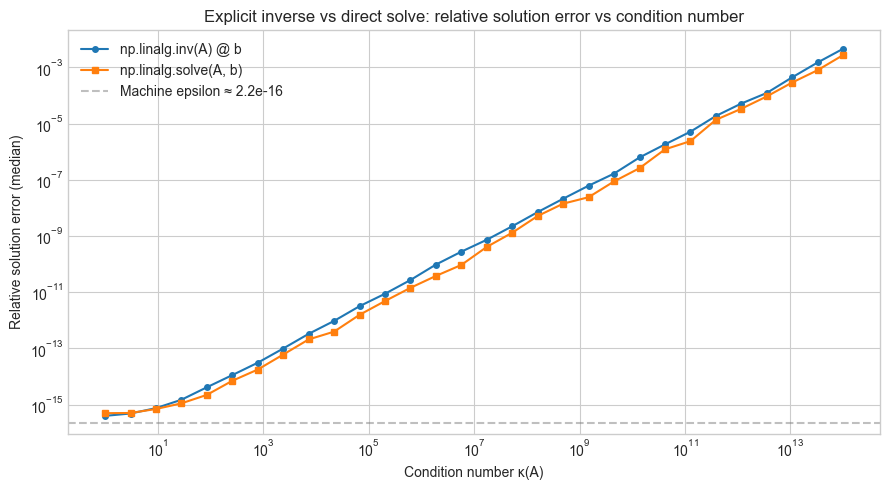

In [7]:
# --- Visualization: Inverse vs solve — numerical accuracy comparison ---
# For Ax = b, compare:
#   (1) x = A^{-1} b  (explicit inverse)
#   (2) x = np.linalg.solve(A, b)  (LU decomposition internally)
# Across a range of condition numbers.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(1)
N = 20
N_TRIALS = 50
KAPPAS = np.logspace(0, 14, 30)  # condition numbers from 1 to 1e14

inv_errors = []
solve_errors = []

for kappa in KAPPAS:
    inv_err_list, solve_err_list = [], []
    for _ in range(N_TRIALS):
        A = make_matrix_with_condition(N, kappa, seed=np.random.randint(0, 10000))
        x_true = np.random.randn(N)
        b = A @ x_true

        # Method 1: explicit inverse
        x_inv = np.linalg.inv(A) @ b
        inv_err_list.append(np.linalg.norm(x_inv - x_true) / (np.linalg.norm(x_true) + 1e-15))

        # Method 2: solve (LU-based)
        x_solve = np.linalg.solve(A, b)
        solve_err_list.append(np.linalg.norm(x_solve - x_true) / (np.linalg.norm(x_true) + 1e-15))

    inv_errors.append(np.median(inv_err_list))
    solve_errors.append(np.median(solve_err_list))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(KAPPAS, inv_errors, 'o-', markersize=4, label='np.linalg.inv(A) @ b')
ax.loglog(KAPPAS, solve_errors, 's-', markersize=4, label='np.linalg.solve(A, b)')
ax.axhline(np.finfo(float).eps, color='gray', linestyle='--', alpha=0.5, label=f'Machine epsilon ≈ {np.finfo(float).eps:.1e}')
ax.set_xlabel('Condition number κ(A)')
ax.set_ylabel('Relative solution error (median)')
ax.set_title('Explicit inverse vs direct solve: relative solution error vs condition number')
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

### Condition number

For a square invertible matrix A, the condition number with respect to a norm ‖·‖ is:

```
κ(A) = ‖A‖ · ‖A⁻¹‖
```

For the 2-norm (spectral norm), this simplifies to:

```
κ₂(A) = σ_max(A) / σ_min(A)
```

Where σ_max and σ_min are the largest and smallest singular values *(ch173 — SVD)*.

The condition number governs the forward error bound: if Ax = b and A(x+δx) = b+δb, then:

```
‖δx‖/‖x‖ ≤ κ(A) · ‖δb‖/‖b‖
```

This bound is tight: there exist perturbations that achieve this amplification exactly.

### Why not compute the inverse

Solving Ax = b via the inverse requires:
1. Compute A⁻¹ (itself a solve against n right-hand sides)
2. Compute A⁻¹b (matrix-vector product)

Step 1 accumulates rounding errors across n independent solves. Direct factorization (LU or QR) solves the specific system Ax = b in O(n³) flops with better error control because it only commits to the specific right-hand side b.

**Rule:** Replace `np.linalg.inv(A) @ b` with `np.linalg.solve(A, b)` whenever solving a linear system.

### QR decomposition for least squares

For overdetermined systems (m > n: more equations than unknowns), the least-squares solution minimizes ‖Ax - b‖². The normal equations give:

```
AᵀAx = Aᵀb
```

But κ(AᵀA) = κ(A)² — squaring the condition number. The QR approach avoids this:

```
A = QR  →  Rx = Qᵀb
```

Condition number is preserved (κ(R) = κ(A)), not squared. Always prefer `np.linalg.lstsq` (which uses QR internally) over solving the normal equations.

### Pseudoinverse via SVD

For any matrix A = UΣVᵀ (including rectangular and rank-deficient), the Moore-Penrose pseudoinverse is:

```
A⁺ = V Σ⁺ Uᵀ
```

Where Σ⁺ replaces each non-zero σᵢ with 1/σᵢ and leaves zeros as zeros. The solution x = A⁺b is the minimum-norm least-squares solution. Numerically, "non-zero" means σᵢ > ε · σ_max where ε is a tolerance (typically 1e-15 for double precision).

---

## 5. Python Implementation

In [8]:
# --- Implementation: Stable linear system tools ---
# A suite of functions demonstrating stable vs unstable approaches
# for common linear algebra tasks.

import numpy as np

def condition_number(A):
    """
    Compute the 2-norm condition number of A using SVD.
    κ₂(A) = σ_max / σ_min
    
    Args:
        A: square or rectangular matrix
    Returns:
        float: condition number (≥ 1, infinity if rank-deficient)
    """
    sv = np.linalg.svd(A, compute_uv=False)
    if sv[-1] < np.finfo(float).eps * sv[0]:
        return np.inf
    return sv[0] / sv[-1]


def stable_solve(A, b):
    """
    Solve Ax = b using LU decomposition.
    Equivalent to np.linalg.solve but with condition number check.
    
    Args:
        A: square matrix (n×n)
        b: right-hand side (n,)
    Returns:
        x: solution vector
    Raises:
        Warning if condition number exceeds 1/machine_epsilon
    """
    kappa = condition_number(A)
    eps = np.finfo(float).eps
    if kappa * eps > 1.0:
        print(f"WARNING: κ(A) = {kappa:.2e} ≥ 1/ε = {1/eps:.2e}")
        print("         Solution may have no significant digits.")
    return np.linalg.solve(A, b)


def stable_least_squares(A, b, rcond=None):
    """
    Solve the least-squares problem: min ‖Ax - b‖₂.
    Uses QR internally (via np.linalg.lstsq).
    Returns minimum-norm solution for rank-deficient A.
    
    Args:
        A: matrix (m×n), m ≥ n typical
        b: right-hand side (m,)
        rcond: relative cutoff for small singular values
    Returns:
        x:       solution (n,)
        residual: ‖Ax - b‖²
        rank:    effective rank of A
    """
    x, res, rank, sv = np.linalg.lstsq(A, b, rcond=rcond)
    residual = float(res[0]) if len(res) > 0 else np.linalg.norm(A @ x - b)**2
    return x, residual, rank


def pseudoinverse(A, tol=None):
    """
    Moore-Penrose pseudoinverse via SVD.
    A⁺ = V Σ⁺ Uᵀ where Σ⁺ inverts non-zero singular values.
    
    Args:
        A:   matrix (m×n)
        tol: threshold for treating singular values as zero
    Returns:
        A_pinv: pseudoinverse (n×m)
    """
    U, sv, Vt = np.linalg.svd(A, full_matrices=False)
    if tol is None:
        tol = np.finfo(float).eps * max(A.shape) * sv[0]
    sv_inv = np.where(sv > tol, 1.0 / sv, 0.0)
    return Vt.T @ np.diag(sv_inv) @ U.T


# --- Test cases ---
np.random.seed(10)

# Well-conditioned system
A_good = np.array([[4.0, 1.0], [2.0, 3.0]])
b_good = np.array([1.0, 2.0])
x_good = stable_solve(A_good, b_good)
print(f"Well-conditioned: κ = {condition_number(A_good):.2f}, solution error: {np.linalg.norm(A_good @ x_good - b_good):.2e}")

# Ill-conditioned system (Hilbert matrix)
n = 10
H = np.array([[1.0/(i+j+1) for j in range(n)] for i in range(n)])  # Hilbert matrix
b_hilbert = H @ np.ones(n)
x_hilbert = stable_solve(H, b_hilbert)  # will warn
print(f"\nHilbert matrix n={n}: true solution is all-ones, recovered solution norm: {np.linalg.norm(x_hilbert):.2f}")
print(f"Error: {np.linalg.norm(x_hilbert - np.ones(n)):.2e}")

# Pseudoinverse on a rank-deficient matrix
print("\nPseudoinverse test:")
A_rd = np.random.randn(6, 4)
A_rd[:, 3] = A_rd[:, 0] + A_rd[:, 1]  # column 3 is linearly dependent
print(f"Rank of A: {np.linalg.matrix_rank(A_rd)} (expected 3, shape is 6x4)")
A_pinv = pseudoinverse(A_rd)
print(f"A⁺ shape: {A_pinv.shape}")
print(f"‖A⁺A - A⁺A‖ (verify A⁺ is left inverse on image): {np.linalg.norm((A_rd @ A_pinv @ A_rd) - A_rd):.2e}")

# Validate pseudoinverse matches numpy
print(f"Matches np.linalg.pinv: {np.allclose(A_pinv, np.linalg.pinv(A_rd))}")

Well-conditioned: κ = 2.62, solution error: 2.22e-16

Hilbert matrix n=10: true solution is all-ones, recovered solution norm: 3.16
Error: 2.74e-04

Pseudoinverse test:
Rank of A: 3 (expected 3, shape is 6x4)
A⁺ shape: (4, 6)
‖A⁺A - A⁺A‖ (verify A⁺ is left inverse on image): 1.58e-15
Matches np.linalg.pinv: True


---

## 6. Experiments

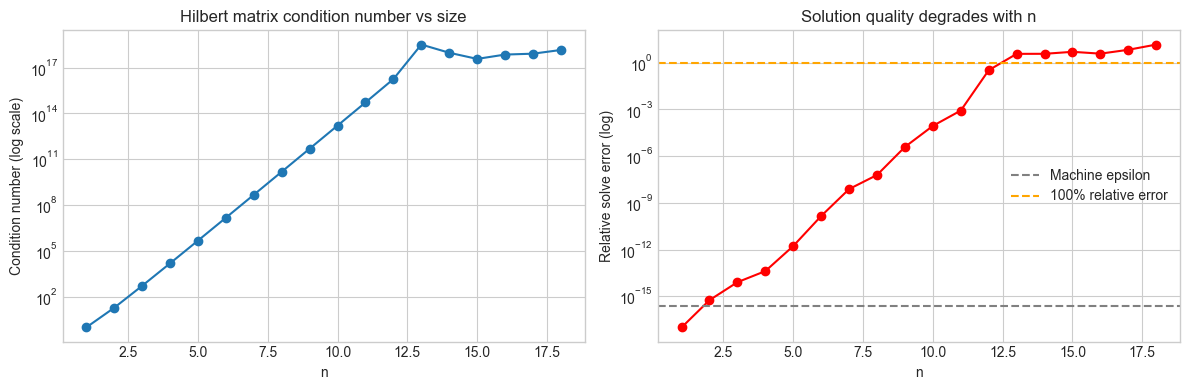

n=8:  κ ≈ 1.5e+10, relative error = 6.1e-08
n=12: κ ≈ 1.8e+16, relative error = 3.2e-01


In [9]:
# --- Experiment 1: Condition number of the Hilbert matrix grows catastrophically ---
# Hypothesis: The Hilbert matrix H_n (H[i,j] = 1/(i+j-1)) has condition number
# that grows exponentially with n, making it numerically singular for small n.
# Try changing: MAX_N to see how far you can go before losing all precision

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

MAX_N = 18   # <-- Try: 10, 15, 20 (beyond ~16, results are meaningless)

ns = list(range(1, MAX_N + 1))
kappas = []
solve_errors = []

for n in ns:
    H = np.array([[1.0/(i+j+1) for j in range(n)] for i in range(n)])
    x_true = np.ones(n)
    b = H @ x_true
    x_solved = np.linalg.solve(H, b)
    kappas.append(np.linalg.cond(H))
    solve_errors.append(np.linalg.norm(x_solved - x_true) / np.linalg.norm(x_true))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(ns, kappas, 'o-')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Condition number (log scale)')
axes[0].set_title('Hilbert matrix condition number vs size')

axes[1].semilogy(ns, [max(e, 1e-17) for e in solve_errors], 'o-', color='red')
axes[1].axhline(np.finfo(float).eps, color='gray', linestyle='--', label='Machine epsilon')
axes[1].axhline(1.0, color='orange', linestyle='--', label='100% relative error')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Relative solve error (log)')
axes[1].set_title('Solution quality degrades with n')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"n=8:  κ ≈ {kappas[7]:.1e}, relative error = {solve_errors[7]:.1e}")
print(f"n=12: κ ≈ {kappas[11]:.1e}, relative error = {solve_errors[11]:.1e}")

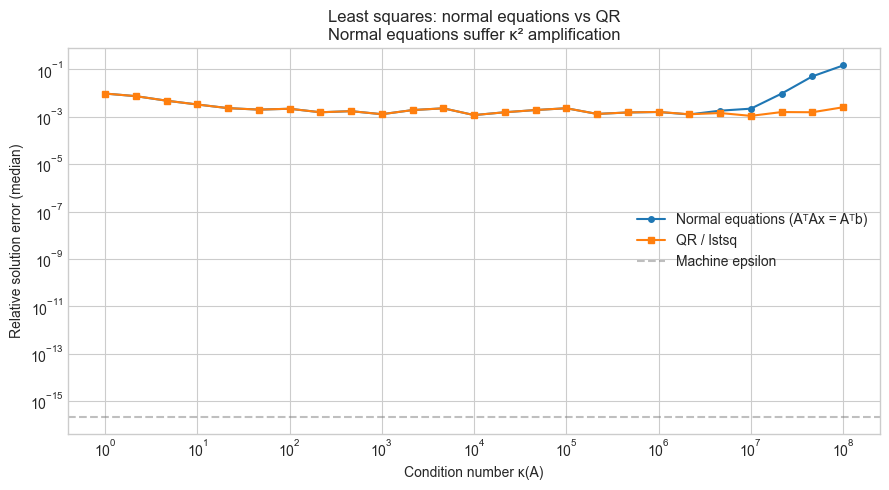

In [10]:
# --- Experiment 2: Normal equations vs QR for least squares ---
# Hypothesis: Solving via normal equations (squaring the condition number)
# is significantly less stable than np.linalg.lstsq (QR-based).
# Try changing: CONDITION to see when normal equations break down

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(5)
M, N = 50, 20   # overdetermined: more equations than unknowns
CONDITIONS = np.logspace(0, 8, 25)
N_TRIALS = 30

normal_errors = []
qr_errors = []

for kappa in CONDITIONS:
    ne_errs, qr_errs = [], []
    for _ in range(N_TRIALS):
        # Construct A with given condition number
        U, _ = np.linalg.qr(np.random.randn(M, N))
        V, _ = np.linalg.qr(np.random.randn(N, N))
        sv = np.linspace(1, kappa, N)
        A = U[:, :N] @ np.diag(sv) @ V.T

        x_true = np.random.randn(N)
        b = A @ x_true + np.random.randn(M) * 0.01  # slight noise

        # Method 1: Normal equations (bad)
        try:
            x_ne = np.linalg.solve(A.T @ A, A.T @ b)
            ne_errs.append(np.linalg.norm(x_ne - x_true) / np.linalg.norm(x_true))
        except np.linalg.LinAlgError:
            ne_errs.append(1.0)

        # Method 2: QR-based (good)
        x_qr, _, _ = stable_least_squares(A, b)
        qr_errs.append(np.linalg.norm(x_qr - x_true) / np.linalg.norm(x_true))

    normal_errors.append(np.median(ne_errs))
    qr_errors.append(np.median(qr_errs))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(CONDITIONS, normal_errors, 'o-', markersize=4, label='Normal equations (AᵀAx = Aᵀb)')
ax.loglog(CONDITIONS, qr_errors, 's-', markersize=4, label='QR / lstsq')
ax.axhline(np.finfo(float).eps, color='gray', linestyle='--', alpha=0.5, label='Machine epsilon')
ax.set_xlabel('Condition number κ(A)')
ax.set_ylabel('Relative solution error (median)')
ax.set_title('Least squares: normal equations vs QR\nNormal equations suffer κ² amplification')
ax.legend()
plt.tight_layout()
plt.show()

Condition number κ(A): 1.0e+08
Orthogonality error:
  Classical Gram-Schmidt: 2.71e-08
  Modified Gram-Schmidt:  1.47e-08
  numpy QR (reference):   2.93e-15


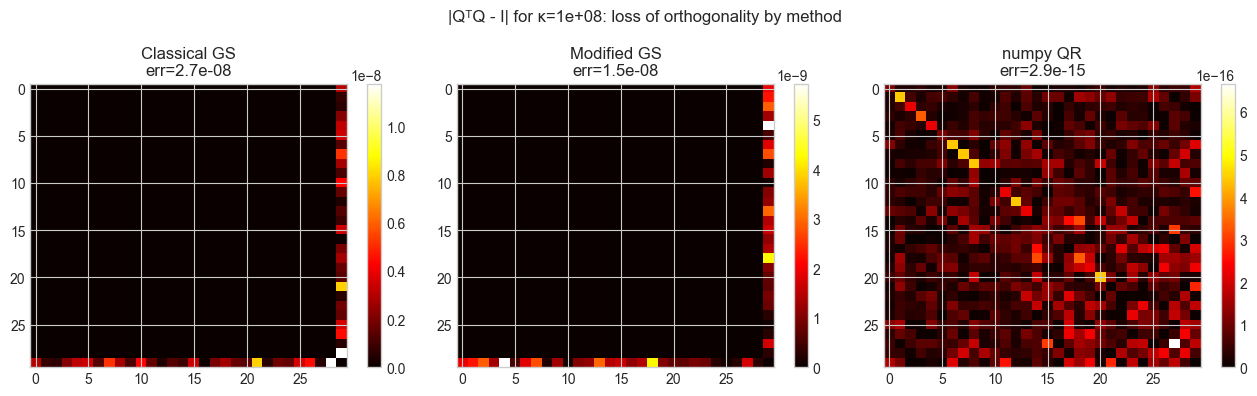

In [11]:
# --- Experiment 3: Gram-Schmidt orthogonalization — classical vs modified ---
# Hypothesis: Classical Gram-Schmidt loses orthogonality for ill-conditioned
# input matrices, while Modified Gram-Schmidt stays accurate much longer.
# Try changing: CONDITION to see where classical GS breaks down

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def classical_gram_schmidt(A):
    """Classical Gram-Schmidt: each column orthogonalized against all previous."""
    m, n = A.shape
    Q = np.zeros_like(A, dtype=float)
    for j in range(n):
        v = A[:, j].astype(float).copy()
        for i in range(j):
            v -= (Q[:, i] @ A[:, j]) * Q[:, i]   # project out prior vectors
        Q[:, j] = v / np.linalg.norm(v)
    return Q

def modified_gram_schmidt(A):
    """Modified Gram-Schmidt: orthogonalize incrementally after each projection."""
    m, n = A.shape
    Q = A.astype(float).copy()
    for j in range(n):
        Q[:, j] /= np.linalg.norm(Q[:, j])
        for k in range(j+1, n):
            Q[:, k] -= (Q[:, j] @ Q[:, k]) * Q[:, j]
    return Q

CONDITION = 1e8   # <-- Try: 1e4, 1e8, 1e12
np.random.seed(3)
N_SIZE = 30

A = make_matrix_with_condition(N_SIZE, CONDITION, seed=3)

Q_cgs = classical_gram_schmidt(A)
Q_mgs = modified_gram_schmidt(A)
Q_numpy, _ = np.linalg.qr(A)  # scipy-level stable reference

def orthogonality_error(Q):
    """‖QᵀQ - I‖_F: how far from orthogonal."""
    return np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]), 'fro')

print(f"Condition number κ(A): {CONDITION:.1e}")
print(f"Orthogonality error:")
print(f"  Classical Gram-Schmidt: {orthogonality_error(Q_cgs):.2e}")
print(f"  Modified Gram-Schmidt:  {orthogonality_error(Q_mgs):.2e}")
print(f"  numpy QR (reference):   {orthogonality_error(Q_numpy):.2e}")

# Visual: QᵀQ matrix for each method
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, Q, title in [
    (axes[0], Q_cgs, f'Classical GS\nerr={orthogonality_error(Q_cgs):.1e}'),
    (axes[1], Q_mgs, f'Modified GS\nerr={orthogonality_error(Q_mgs):.1e}'),
    (axes[2], Q_numpy, f'numpy QR\nerr={orthogonality_error(Q_numpy):.1e}'),
]:
    im = ax.imshow(np.abs(Q.T @ Q - np.eye(N_SIZE)), cmap='hot', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle(f'|QᵀQ - I| for κ={CONDITION:.0e}: loss of orthogonality by method', fontsize=12)
plt.tight_layout()
plt.show()

---

## 7. Exercises

**Easy 1.** Compute the condition number of the 5×5 Hilbert matrix using two methods: (a) `np.linalg.cond(H)` and (b) `np.linalg.svd(H, compute_uv=False)[0] / np.linalg.svd(H, compute_uv=False)[-1]`. Verify they match. What does this value mean for a system solved with double precision (machine epsilon ≈ 1e-16)? *(Expected: κ ≈ 4.77e5; roughly 5-6 digits of precision are lost)*

**Easy 2.** For the 3×3 rotation matrix R(θ) = [[cos θ, -sin θ, 0], [sin θ, cos θ, 0], [0, 0, 1]], compute the condition number for several values of θ. What do you observe? Why? *(Expected: κ = 1 for all θ — rotation matrices are orthogonal with all singular values = 1)*

**Medium 1.** The covariance matrix in PCA *(ch174)* is often computed as `C = (X - mean) @ (X - mean).T / n`. If X is nearly rank-deficient (more features than samples), C will be singular. Implement a robust PCA that: (a) detects rank deficiency by inspecting singular values of X directly, (b) discards directions with σ < ε · σ_max, (c) returns only the stable principal components. Test it on a 100×50 data matrix where 20 features are linear combinations of the others.

**Medium 2.** Compare solving the linear system Ax = b using: (a) `np.linalg.solve`, (b) `np.linalg.lstsq`, and (c) explicit pseudoinverse via SVD. For a well-conditioned square system, all three should agree. For an overdetermined system, which gives the minimum-norm solution? For a rank-deficient system, which fails silently and which handles it gracefully? *(Hint: test on rank-deficient 4×4 matrix)*

**Hard.** Implement the RRQR (rank-revealing QR) algorithm: a column-pivoted QR decomposition that reorders columns to reveal the numerical rank. The key property: after pivoting, the (r+1,r+1) entry of R is small when the matrix has numerical rank r. Implement column pivoting in the modified Gram-Schmidt framework: at each step, choose the column with largest remaining norm as the next pivot. Verify that your implementation correctly identifies the rank of a 6×6 matrix constructed as the product of two 6×3 matrices. *(Challenge: the diagonal of R should decay, with a gap at the true rank)*

---

## 8. Mini Project — Diagnosing a Numerically Fragile Linear Regression

In [ ]:
# --- Mini Project: Diagnosing and fixing a numerically fragile regression ---
# Problem: A feature matrix X contains near-collinear columns.
#          Fitting via normal equations gives wildly unstable coefficients.
#          Diagnose the problem using SVD, then fix it with ridge regularization
#          and compare to the QR-based solution.
# Dataset: Generated with controlled near-collinearity

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
N_SAMPLES = 100
N_FEATURES = 6

# Generate feature matrix with near-collinearity
X_base = np.random.randn(N_SAMPLES, 3)
noise_level = 1e-3   # <-- Try: 1e-1 (mild), 1e-3 (moderate), 1e-6 (severe)
X = np.hstack([
    X_base,
    X_base[:, 0:1] + X_base[:, 1:2] + np.random.randn(N_SAMPLES, 1) * noise_level,  # nearly col1+col2
    X_base[:, 2:3] * 2 + np.random.randn(N_SAMPLES, 1) * noise_level,                # nearly 2*col3
    np.random.randn(N_SAMPLES, 1),  # independent noise feature
])

TRUE_COEF = np.array([1.5, -2.0, 0.8, 0.0, 0.0, 0.3])
y = X @ TRUE_COEF + np.random.randn(N_SAMPLES) * 0.1

# --- Step 1: Diagnose via SVD ---
U, sv, Vt = np.linalg.svd(X, full_matrices=False)
kappa = sv[0] / sv[-1]
print("=== Diagnosis ===")
print(f"Singular values of X: {sv.round(3)}")
print(f"Condition number κ(X): {kappa:.2e}")
print(f"Digits of precision lost: ~{np.log10(kappa):.1f}")

# --- Step 2: Normal equations (unstable) ---
coef_ne = np.linalg.solve(X.T @ X, X.T @ y)

# --- Step 3: QR-based least squares (stable) ---
coef_qr, _, _ = stable_least_squares(X, y)

# --- Step 4: Ridge regression (regularized, adds λI to AᵀA) ---
LAMBDA = 0.1   # <-- Try: 0.001, 0.1, 1.0, 10.0
coef_ridge = np.linalg.solve(X.T @ X + LAMBDA * np.eye(N_FEATURES), X.T @ y)

# --- Compare ---
print("\n=== Coefficient comparison ===")
print(f"{'Feature':<10} {'True':>8} {'NormEq':>10} {'QR':>10} {'Ridge':>10}")
print("-" * 50)
for i, (tc, ne, qr, ri) in enumerate(zip(TRUE_COEF, coef_ne, coef_qr, coef_ridge)):
    print(f"Feature {i+1}:  {tc:>8.3f} {ne:>10.3f} {qr:>10.3f} {ri:>10.3f}")

print(f"\n‖coef_ne - true‖:    {np.linalg.norm(coef_ne - TRUE_COEF):.4f}")
print(f"‖coef_qr - true‖:    {np.linalg.norm(coef_qr - TRUE_COEF):.4f}")
print(f"‖coef_ridge - true‖: {np.linalg.norm(coef_ridge - TRUE_COEF):.4f}")

# --- Visualize singular value spectrum and coefficient comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(range(1, N_FEATURES+1), sv, 'o-')
axes[0].set_xlabel('Index'); axes[0].set_ylabel('Singular value (log)')
axes[0].set_title(f'Singular value spectrum of X\nκ = {kappa:.1e}')

x_pos = np.arange(N_FEATURES)
width = 0.2
axes[1].bar(x_pos - 1.5*width, TRUE_COEF, width, label='True', alpha=0.8)
axes[1].bar(x_pos - 0.5*width, coef_qr, width, label='QR', alpha=0.8)
axes[1].bar(x_pos + 0.5*width, coef_ridge, width, label='Ridge', alpha=0.8)
axes[1].bar(x_pos + 1.5*width, coef_ne, width, label='Normal Eq.', alpha=0.8)
axes[1].set_xlabel('Feature'); axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Regression coefficients: true vs estimated')
axes[1].legend()
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'F{i+1}' for i in range(N_FEATURES)])

plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What this chapter covered:**
- The condition number κ(A) = σ_max / σ_min quantifies how much a matrix amplifies errors: a relative error ε in b can produce a relative error κε in the solution x.
- Never compute the matrix inverse explicitly for linear system solving — always use `np.linalg.solve` (LU-based), which is both faster and more numerically stable.
- For least squares (overdetermined systems), use `np.linalg.lstsq` (QR-based) instead of the normal equations (AᵀAx = Aᵀb), which squares the condition number.
- The pseudoinverse via SVD handles rank-deficient systems gracefully, returning the minimum-norm least-squares solution while discarding numerically zero singular directions.
- Modified Gram-Schmidt orthogonalization is substantially more numerically stable than classical Gram-Schmidt for ill-conditioned inputs, though both are superseded by Householder QR in practice.

**Forward connections:**
- Every project chapter in this Part (ch180–ch191) uses linear system solving or SVD. The stability principles from this chapter are the reason the project implementations use `np.linalg.lstsq` and `np.linalg.svd` rather than the inverse.
- Ridge regularization (λI term) will reappear in ch271 (Regression) as the standard treatment for ill-conditioned design matrices, with the regularization parameter λ connected to a prior over coefficient magnitudes via Bayesian linear regression.
- The pseudoinverse and numerical rank concept return in ch273 (Dimensionality Reduction) when we discuss how to choose the truncation threshold in PCA.

**Backward connection:**
- The condition number formula κ = σ_max / σ_min is a direct consequence of the SVD geometry *(ch173)*: the largest singular value is the maximum amplification, the smallest is the minimum. Their ratio measures the "spread" of the transformation.

**Going deeper:** Backward error analysis (Wilkinson, 1963) is the framework that makes statements like "algorithm X is backward stable" precise. A backward stable algorithm produces the exact solution to a slightly perturbed problem. LAPACK's routines (used internally by numpy) are designed to be backward stable for standard linear algebra operations.